# **Breakdown of this notebook:**

1. Data Visualization
      * Importing Libraries
      * Loading Datasets
      * Data Cleaning (removing duplicates, null values etc)
      * Plots include :
                        1) Scatter Plot
                        2) Histograms
                        3) Pair Plots
                        4) Box Plots
                        5) Bar graph
                        6) KDE Plots
                        7) Heatmap
                        8) Sub Plots
2. Linear Regression Analysis
      * Multivariable Linear Regression
      * Predict the species of flower based on dimensions of petals and sepals.
3. Decision Tree Analysis
      * Based on Zomato Restaurant Data.
      * Predict Approximate cost of food/dining in restaurant based on dependant variables






# **DATA VISUALIZATION**

In [ ]:
#import libraries
import pandas as pd
import numpy as np

# importing packages
import seaborn as sns
import matplotlib.pyplot as plt

Please be cautious: Do not execute the following cell, as the specified path may not be available in the user's environment. If the cell has already been executed, please refresh or reload the webpage to restore it to its original state.

In [ ]:
# Reading the CSV file
df = pd.read_csv("/content/drive/MyDrive/Data Analysis Project/Iris.csv")

# Printing top 15 rows
df.sample(15)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
123,124,6.3,2.7,4.9,1.8,Iris-virginica
15,16,5.7,4.4,1.5,0.4,Iris-setosa
105,106,7.6,3.0,6.6,2.1,Iris-virginica
72,73,6.3,2.5,4.9,1.5,Iris-versicolor
65,66,6.7,3.1,4.4,1.4,Iris-versicolor
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
44,45,5.1,3.8,1.9,0.4,Iris-setosa
14,15,5.8,4.0,1.2,0.2,Iris-setosa
80,81,5.5,2.4,3.8,1.1,Iris-versicolor
37,38,4.9,3.1,1.5,0.1,Iris-setosa


In [ ]:
df["Species"].unique() #checking unique values

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [ ]:
df.shape

(150, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


**Checking Missing Values**

In [ ]:
df.isnull().sum() #checking null values

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
data = df.drop_duplicates(subset ="Species")  #dropping duplicates
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
100,101,6.3,3.3,6.0,2.5,Iris-virginica


In [ ]:
df.value_counts("Species")

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


**Data Visualization**

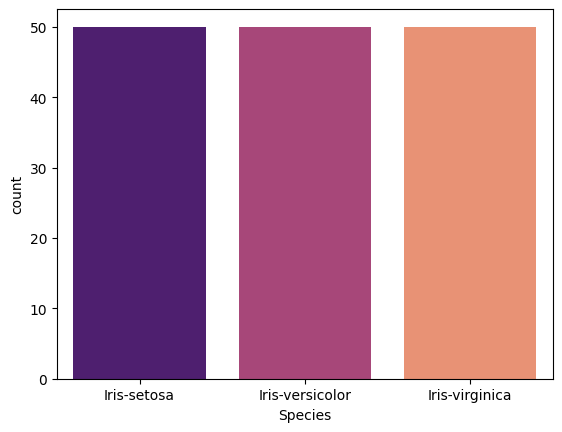

In [ ]:
#Count_plot

sns.countplot(x='Species', hue = 'Species', data=df, palette='magma')
plt.show()

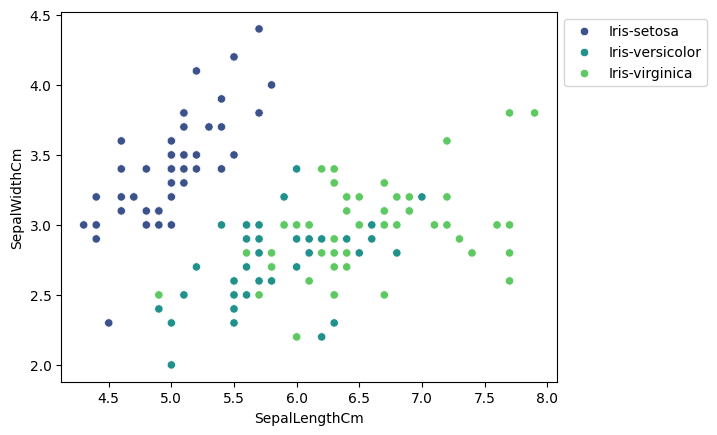

In [ ]:
#Scatter_plot

sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm',
                hue='Species', data=df, palette = 'viridis' )

# Placing Legend outside the Figure
plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

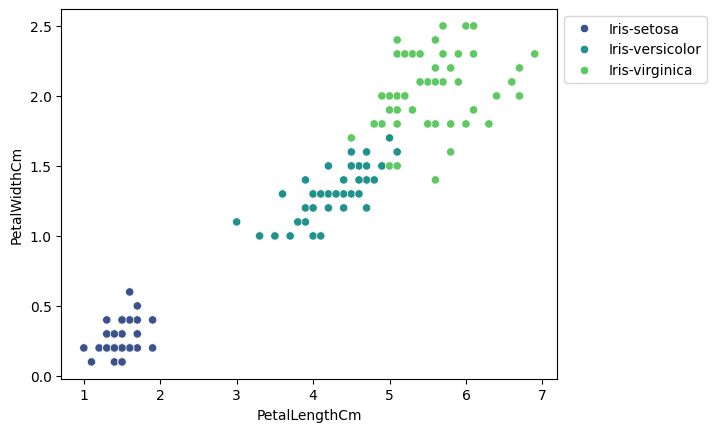

In [ ]:
#Scatter_plot

sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm',
                hue='Species', data=df,palette = 'viridis' )

# Placing Legend outside the Figure
plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

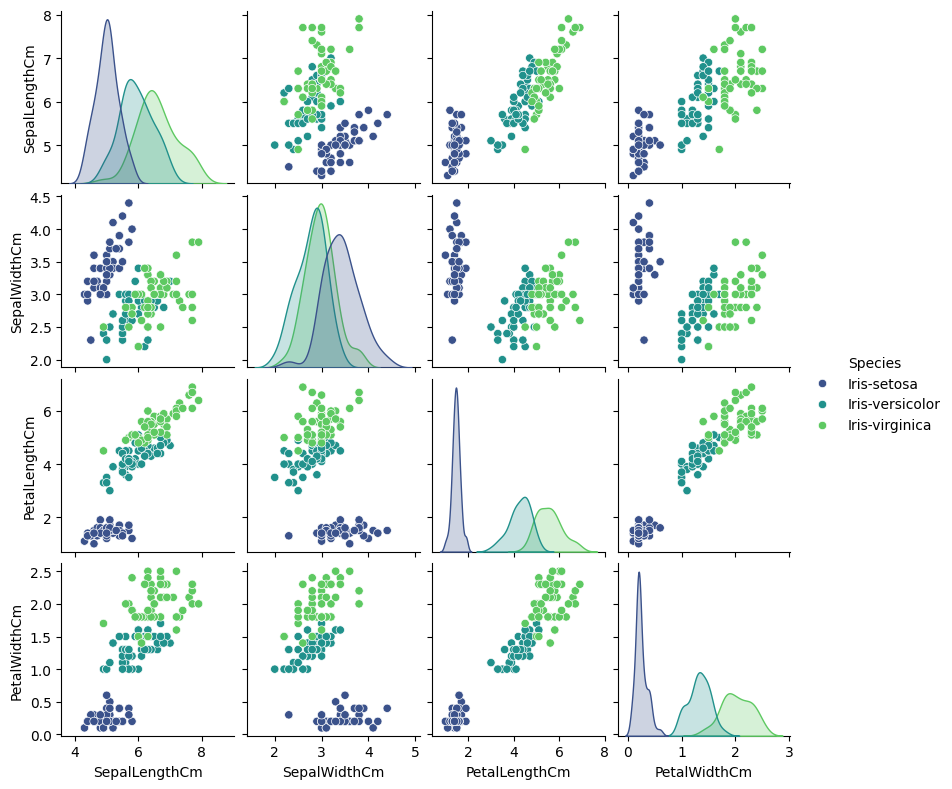

In [ ]:
#pair plots
sns.pairplot(df.drop(['Id'], axis = 1),
             hue='Species', height=2, palette = 'viridis')

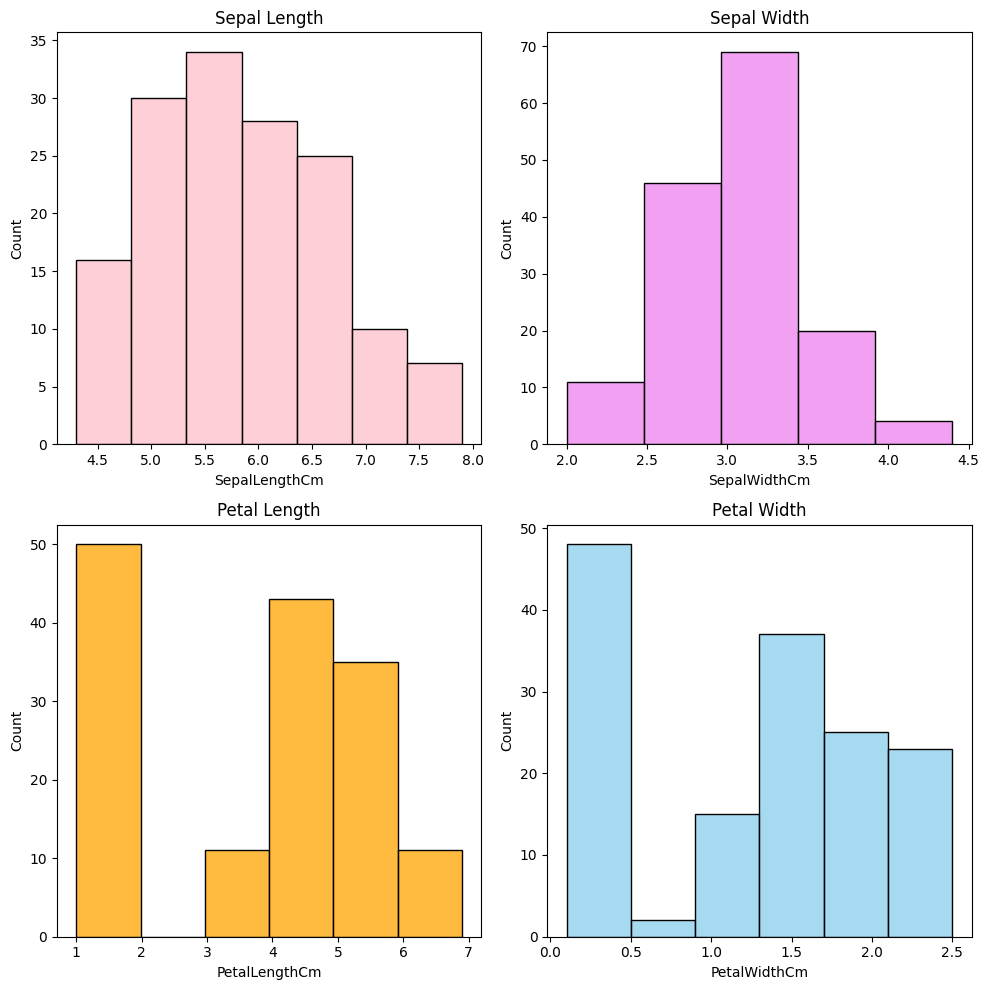

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# For Sepal Length
axes[0, 0].set_title("Sepal Length")
sns.histplot(df['SepalLengthCm'], bins=7, color='pink', ax=axes[0, 0])

# For Sepal Width
axes[0, 1].set_title("Sepal Width")
sns.histplot(df['SepalWidthCm'], bins=5, color='violet', ax=axes[0, 1])

# For Petal Length
axes[1, 0].set_title("Petal Length")
sns.histplot(df['PetalLengthCm'], bins=6, color='orange', ax=axes[1, 0])

# For Petal Width
axes[1, 1].set_title("Petal Width")
sns.histplot(df['PetalWidthCm'], bins=6, color='skyblue', ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [ ]:
# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=['float', 'int'])

# Calculate correlation on numeric data
numeric_data.corr(method='pearson')

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,1.000000,0.624413,-0.654654,0.969909,0.999685
SepalLengthCm,0.624413,1.000000,-0.999226,0.795795,0.643817
SepalWidthCm,-0.654654,-0.999226,1.000000,-0.818999,-0.673417
PetalLengthCm,0.969909,0.795795,-0.818999,1.000000,0.975713
PetalWidthCm,0.999685,0.643817,-0.673417,0.975713,1.000000


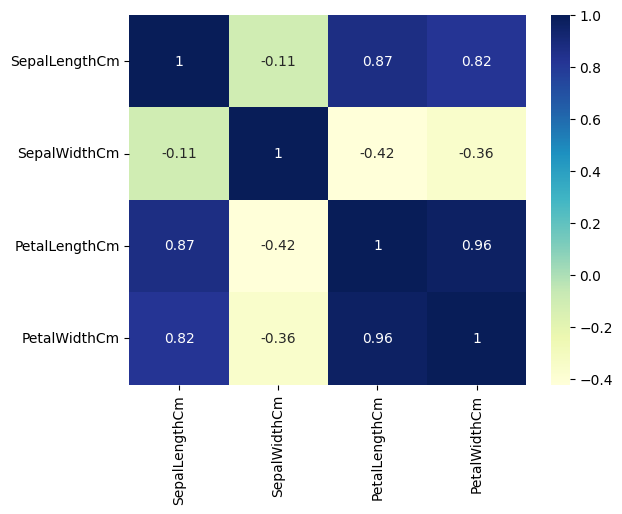

In [ ]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float', 'int'])

numeric_dff = numeric_df.drop(['Id'], axis = 1)

# Calculate correlation on numeric data
numeric_dff.corr(method='pearson')


# Plotting the heatmap with 'magma' color palette
sns.heatmap(numeric_dff.corr(method='pearson'),
            annot=True,
            cmap='YlGnBu')  # Set the palette to 'YlGnBu'

plt.show()

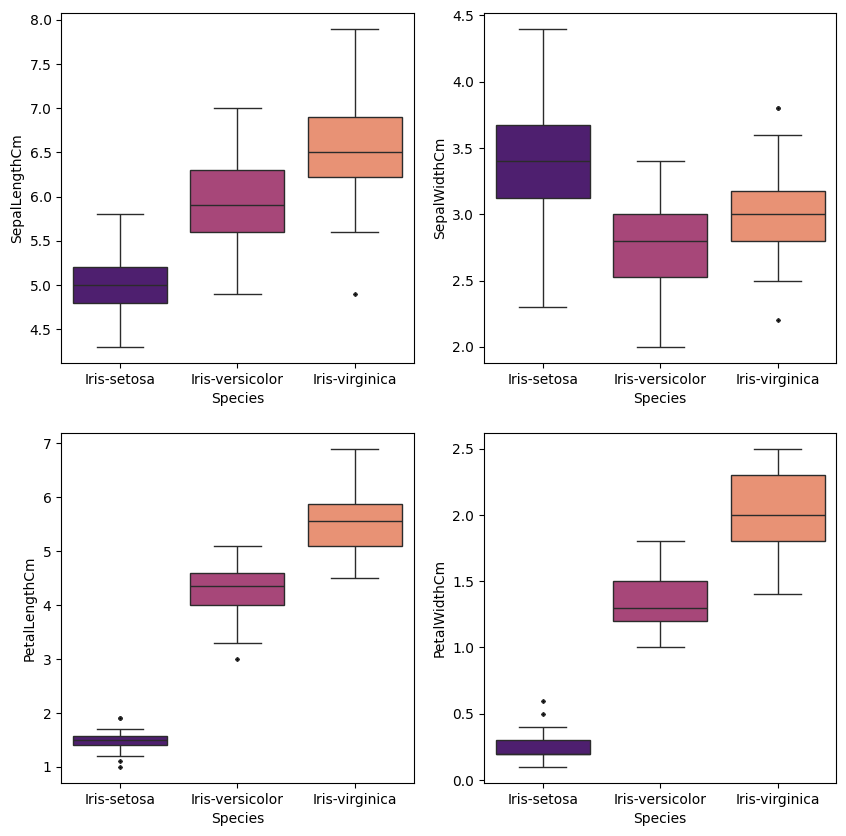

In [ ]:
def graph(y):
    # Customizing the flier (outlier) properties to show diamonds
    flierprops = dict(marker='D', markerfacecolor='black', markersize=2, linestyle='none')

    sns.boxplot(
        x="Species",
        y=y,
        hue="Species",
        data=df,
        palette='magma',
        dodge=False,
        legend=False,
        flierprops=flierprops  # Set the properties for outliers
    )

plt.figure(figsize=(10, 10))

# Adding the subplot at the specified grid position
plt.subplot(221)
graph('SepalLengthCm')

plt.subplot(222)
graph('SepalWidthCm')

plt.subplot(223)
graph('PetalLengthCm')

plt.subplot(224)
graph('PetalWidthCm')

plt.show()

<Axes: xlabel='SepalWidthCm'>

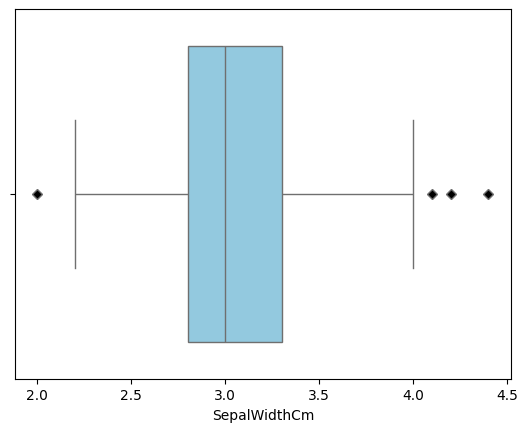

In [ ]:
#fixing oulier dimentions

flierprops = dict(marker='D', markerfacecolor='black', markersize=5)
sns.boxplot(x='SepalWidthCm', data=df, color = "skyblue", flierprops=flierprops)

Old Shape:  (150, 6)
New Shape:  (146, 6)


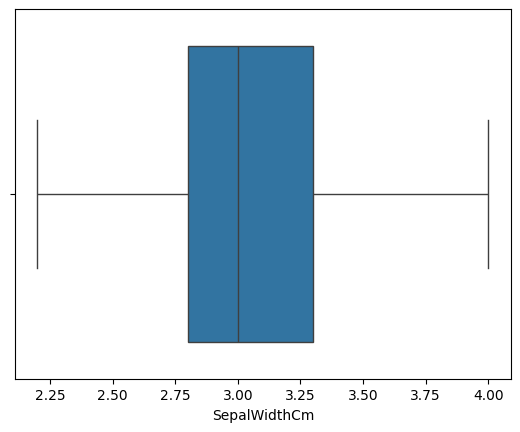

In [ ]:
# IQR
Q1 = np.percentile(df['SepalWidthCm'], 25, interpolation = 'midpoint')
Q3 = np.percentile(df['SepalWidthCm'], 75, interpolation = 'midpoint')
IQR = Q3 - Q1

print("Old Shape: ", df.shape)

# Upper bound
upper = np.where(df['SepalWidthCm'] >= (Q3+1.5*IQR))

# Lower bound
lower = np.where(df['SepalWidthCm'] <= (Q1-1.5*IQR))

# Removing the Outliers
df.drop(upper[0], inplace = True)
df.drop(lower[0], inplace = True)

print("New Shape: ", df.shape)

sns.boxplot(x='SepalWidthCm', data=df)
plt.show() # Add this line to display the plot

# **Linear Regression Analysis**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn import linear_model

In [ ]:
# Reading the CSV file
df = pd.read_csv("/content/drive/MyDrive/Data Analysis Project/Iris.csv")

# Printing top 15 rows
df.sample(15)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
141,142,6.9,3.1,5.1,2.3,Iris-virginica
55,56,5.7,2.8,4.5,1.3,Iris-versicolor
113,114,5.7,2.5,5.0,2.0,Iris-virginica
88,89,5.6,3.0,4.1,1.3,Iris-versicolor
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
120,121,6.9,3.2,5.7,2.3,Iris-virginica
87,88,6.3,2.3,4.4,1.3,Iris-versicolor
135,136,7.7,3.0,6.1,2.3,Iris-virginica
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
124,125,6.7,3.3,5.7,2.1,Iris-virginica


In [ ]:
l_Species = LabelEncoder()
df["Species"] = l_Species.fit_transform(df["Species"])
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
7,8,5.0,3.4,1.5,0.2,0
136,137,6.3,3.4,5.6,2.4,2
52,53,6.9,3.1,4.9,1.5,1
123,124,6.3,2.7,4.9,1.8,2
130,131,7.4,2.8,6.1,1.9,2


In [ ]:
# Print the encoding mapping
label_mapping = dict(zip(l_Species.classes_, l_Species.transform(l_Species.classes_)))
print("Label Encoding Mapping:")
for original, encoded in label_mapping.items():
    print(f"{original} -> {encoded}")

Label Encoding Mapping:
Iris-setosa -> 0
Iris-versicolor -> 1
Iris-virginica -> 2


In [ ]:
df.isnull().values.any()

False

In [ ]:
reg = linear_model.LinearRegression()
reg.fit(df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']], df.Species)

LinearRegression()

In [ ]:
reg.coef_

array([-0.10974146, -0.04424045,  0.22700138,  0.60989412])

In [ ]:
reg.intercept_

0.19208399482813898

In [ ]:
#['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
inputs = [6, 1.8, 5, 2]

# Check for any zero inputs
if any(i == 0 for i in inputs):
    print("Not valid Input")
else:
    prediction = reg.predict([inputs])
    print(prediction)

    # Check if the prediction is less than or equal to the threshold
    if prediction[0] <= 0.19208399:
        print("Not valid Input")
    else:
        print("Valid Input")

[1.80879756]
Valid Input


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Round the predicted value to the nearest integer and convert it to an integer type.

rounded_prediction = np.round(prediction).astype(int)

# Check the value of 'rounded_prediction' and print the corresponding Iris flower species.

if rounded_prediction == 0:
   print("Iris-setosa")
elif rounded_prediction == 1:
   print("Iris-versicolor")
elif rounded_prediction == 2:
   print("Iris-virginica")
else:
   print("Please input valid data")

Iris-virginica


# **Decision Tree Analysis**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

Please be cautious: Do not execute the following cell, as the specified path may not be available in the user's environment. If the cell has already been executed, please refresh or reload the webpage to restore it to its original state.

In [ ]:
# Reading the CSV file
Zomato = pd.read_csv("/content/drive/MyDrive/Data Analysis Project/zomato.csv")

# Printing top 5 rows
Zomato.sample(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
31533,https://www.zomato.com/bangalore/subham-pal-ki...,"998, 1st Main Road, Jakkasandra Road, Koramang...",Subham Pal Kitchen,Yes,No,3.3 /5,10,+91 7624814763,Koramangala 1st Block,Quick Bites,NaN,"North Indian, Chinese",300,"[('Rated 5.0', ""RATED\n friendly people north...",[],Dine-out,Koramangala 5th Block
20480,https://www.zomato.com/bangalore/new-rajadhani...,"16, Lalitha Enterprises, Kadirenahalli Main, B...",New Rajadhani Spicy,Yes,No,3.7/5,67,+91 8971562572,Kumaraswamy Layout,Casual Dining,NaN,North Indian,700,"[('Rated 3.0', 'RATED\n Called their Egg Masa...",[],Delivery,Jayanagar
47829,https://www.zomato.com/bangalore/peppa-zzing-i...,"G-18, Kedia Arcade, 92, Infantry Road, Bangalore",Peppa Zzing,Yes,No,4.3 /5,1135,+91 9740758557,Infantry Road,Cafe,"Burgers, Pasta, Cheesy Fries, Beef Burger, Ice...","Cafe, Fast Food, Burger",800,"[('Rated 5.0', 'RATED\n This is a classic bur...","['Chicken Burger', 'Beef Burger', 'Beef Steak ...",Delivery,Residency Road
46537,https://www.zomato.com/bangalore/dharwad-line-...,"45/1, Sampige Road, Opposite Expert Dry Cleane...",Dharwad Line Bazar Mishra Pedha,No,No,3.4 /5,4,+91 8123999224,Malleshwaram,Sweet Shop,NaN,Mithai,150,[],[],Delivery,Rajajinagar
45356,https://www.zomato.com/bangalore/loveshack-dom...,"280, Amarjyothi Layout, Opposite DELL, Inner R...",Loveshack,No,Yes,4.0 /5,1806,080 40959154\n+91 9900034528,Domlur,"Lounge, Cafe","Corn Balls, Cocktails, Mocktails, Sunday Brunc...","Continental, Pizza, North Indian, Goan, Cafe","1,600","[('Rated 3.0', 'RATED\n Quick tip:- happy hou...",[],Delivery,Old Airport Road


In [ ]:
Zomato.dropna(inplace = True) #droping null values

In [ ]:
Zomato.drop_duplicates(inplace = True) #droping duplicates

In [ ]:
Zomato.shape

(23193, 17)

In [ ]:
Zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23193 entries, 0 to 51715
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          23193 non-null  object
 1   address                      23193 non-null  object
 2   name                         23193 non-null  object
 3   online_order                 23193 non-null  object
 4   book_table                   23193 non-null  object
 5   rate                         23193 non-null  object
 6   votes                        23193 non-null  int64 
 7   phone                        23193 non-null  object
 8   location                     23193 non-null  object
 9   rest_type                    23193 non-null  object
 10  dish_liked                   23193 non-null  object
 11  cuisines                     23193 non-null  object
 12  approx_cost(for two people)  23193 non-null  object
 13  reviews_list                 23193 n

In [ ]:
Zomato.describe()

,votes
count,23193.000000
mean,601.074462
std,1114.854301
min,0.000000
25%,101.000000
50%,221.000000
75%,586.000000
max,16832.000000


In [ ]:
Zomato.drop(['url', 'address', 'reviews_list','menu_item', 'phone', 'votes','location','dish_liked' ], axis=1, inplace = True) #dropping columns

In [ ]:
Zomato.drop(['cuisines' ], axis=1, inplace = True)

In [ ]:
Zomato.drop_duplicates(inplace = True) #droping duplicates

In [ ]:
Zomato.shape

(23151, 8)

In [ ]:
#start

In [ ]:
# Drop the 'approx_cost(for two people)' column from the DataFrame 'Zomato' to create the input features.
inputs = Zomato.drop('approx_cost(for two people)', axis = 'columns')

# Select only the 'approx_cost(for two people)' column from the DataFrame 'Zomato' to create the target variable.
target = Zomato[['approx_cost(for two people)']]

In [ ]:
l_Cost = LabelEncoder() #Encoding

In [ ]:
target['Cost_n'] = l_Cost.fit_transform(target['approx_cost(for two people)']) #Encoding

<ipython-input-44-116f4a9de3b1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target['Cost_n'] = l_Cost.fit_transform(target['approx_cost(for two people)']) #Encoding


In [ ]:
target_n = target.drop(['approx_cost(for two people)'], axis = 'columns')
target_n.sample(5)

,Cost_n
11688,43
3198,43
21809,49
36766,53
26693,43


In [ ]:
#Encoding

l_name = LabelEncoder()
l_online = LabelEncoder()
l_table = LabelEncoder()
l_rate = LabelEncoder()
l_rest = LabelEncoder()
l_listed = LabelEncoder()
l_city = LabelEncoder()

In [ ]:
#Encoding

inputs['name_n'] = l_name.fit_transform(inputs['name'])
inputs['online_order_n'] = l_online.fit_transform(inputs['online_order'])
inputs['book-table_n'] = l_table.fit_transform(inputs['book_table'])
inputs['rate_n'] = l_rate.fit_transform(inputs['rate'])
inputs['rest_type_n'] = l_rest.fit_transform(inputs['rest_type'])
inputs['listed_in(type)_n'] = l_listed.fit_transform(inputs['listed_in(type)'])
inputs['listed_in(city)_n'] = l_city.fit_transform(inputs['listed_in(city)'])

In [ ]:
inputs_n = inputs.drop(['name',	'online_order',	'book_table',	'rate',	'rest_type',	'listed_in(type)',	'listed_in(city)'], axis = 'columns')
inputs_n.sample(10)

,name_n,online_order_n,book-table_n,rate_n,rest_type_n,listed_in(type)_n,listed_in(city)_n
25175,2865,0,0,49,13,1,15
31540,1802,1,0,40,62,4,17
19169,1227,0,0,37,62,4,11
51617,420,0,0,34,62,4,29
38639,2446,0,1,46,60,4,20
26485,2876,0,0,37,4,5,15
29962,1134,1,0,26,20,2,17
26963,1967,1,0,37,72,2,16
29013,1383,1,0,24,62,4,16
21816,1079,1,1,49,22,1,12


In [ ]:
model = tree.DecisionTreeClassifier()

In [ ]:
model.fit(inputs_n, target_n)

DecisionTreeClassifier()

In [ ]:
#Achieved Accuracy
model.score(inputs_n, target_n)

0.9996112478942595

In [ ]:
#['name',	'online_order',	'book_table',	'rate',	'rest_type',	'listed_in(type)',	'listed_in(city)']
encoded_prediction = model.predict([[183, 0, 0, 4, 20, 4, 22]])
print(encoded_prediction)

[43]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#Decoding the 'encoded_prediction' back to its original value.

decoded_prediction = l_Cost.inverse_transform([encoded_prediction[0]])

print(f"Encoded Prediction: {encoded_prediction[0]}")
print(f"Decoded Prediction (Approx Cost for Two People): {decoded_prediction[0]}")

Encoded Prediction: 43
Decoded Prediction (Approx Cost for Two People): 400
